# ==============================================================================
# 🏗️ STRUCTURAL SAFETY BOUNDS: CONCRETE STRENGTH VIA MULTI-QUANTILE REGRESSION
# ==============================================================================
### Structural Engineering Motivation:
In civil construction, predicting mean compressive strength is inadequate. Structural safety codes (e.g., ACI 318, Eurocode 2) require guarantees on the **characteristic strength**, defined as the 5th or 10th percentile ($q = 0.10$), below which no more than 10% of batches fail. Multi-quantile regression predicts the 10th, 50th, and 90th percentiles simultaneously to provide full uncertainty intervals!


In [1]:
# STEP 1: ENTERPRISE ENVIRONMENT & REPRODUCIBILITY SEED
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import QuantileRegressor, LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_pinball_loss, mean_absolute_error, r2_score

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("✅ STEP 1: Concrete Safety Multi-Quantile Regression initialized.")


✅ STEP 1: Concrete Safety Multi-Quantile Regression initialized.


In [2]:
# STEP 2: DATA INGESTION & STRATEGIC SPLIT
data_path = 'data/concrete/Concrete Compressive Strength.csv' if os.path.exists('data/concrete/Concrete Compressive Strength.csv') else 'data/concrete/concrete.csv'
df = pd.read_csv(data_path)
df.columns = [c.strip().lower().replace(' ', '_').replace('(', '').replace(')', '') for c in df.columns]

target = 'concrete_compressive_strength'
features = [c for c in df.columns if c != target]

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"Data shape: {df.shape} | Training: {X_train.shape} | Test: {X_test.shape}")
df.head()


Data shape: (1030, 9) | Training: (824, 8) | Test: (206, 8)


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age_day,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


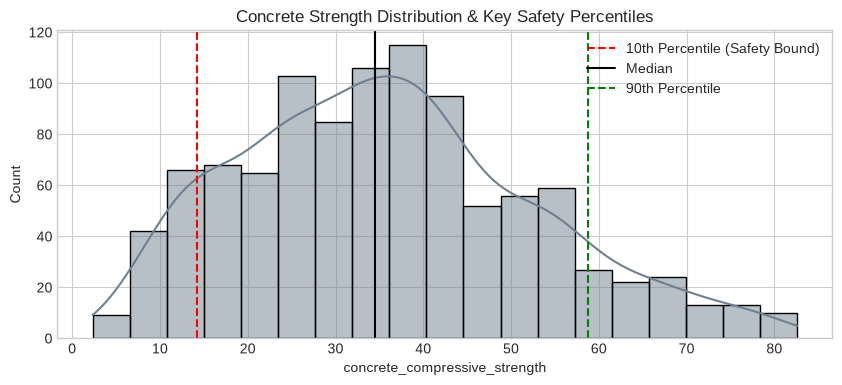

In [3]:
# STEP 3: EDA & COMPONENT DISTRIBUTIONS
plt.figure(figsize=(10, 4))
sns.histplot(y, kde=True, color='slategray')
plt.axvline(np.percentile(y, 10), color='red', linestyle='--', label='10th Percentile (Safety Bound)')
plt.axvline(np.median(y), color='black', linestyle='-', label='Median')
plt.axvline(np.percentile(y, 90), color='green', linestyle='--', label='90th Percentile')
plt.legend()
plt.title('Concrete Strength Distribution & Key Safety Percentiles')
plt.show()


In [4]:
# STEP 4 & 6: TRAINING MULTI-QUANTILE ENSEMBLE (q=0.1, 0.5, 0.9)
quantiles = [0.1, 0.5, 0.9]
models = {}

for q in quantiles:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', QuantileRegressor(quantile=q, alpha=0.01, solver='highs'))
    ])
    pipe.fit(X_train, y_train)
    models[q] = pipe
    print(f"Trained Quantile Model q={q}")


Trained Quantile Model q=0.1
Trained Quantile Model q=0.5
Trained Quantile Model q=0.9


In [5]:
# STEP 7: EVALUATION & SAFETY INTERVAL ESTIMATION
predictions = {}
for q, model in models.items():
    pred = model.predict(X_test)
    predictions[q] = pred
    pb_loss = mean_pinball_loss(y_test, pred, alpha=q)
    print(f"Quantile q={q} | Test Pinball Loss: {pb_loss:.4f} MPa")

# Coverage check: Percentage of actual values between q=0.1 and q=0.9
in_bounds = (y_test.values >= predictions[0.1]) & (y_test.values <= predictions[0.9])
coverage = np.mean(in_bounds) * 100
print(f"Empirical 80% Safety Prediction Interval Coverage: {coverage:.2f}% (Nominal: 80%)")


Quantile q=0.1 | Test Pinball Loss: 1.6819 MPa
Quantile q=0.5 | Test Pinball Loss: 3.9885 MPa
Quantile q=0.9 | Test Pinball Loss: 1.5643 MPa
Empirical 80% Safety Prediction Interval Coverage: 81.55% (Nominal: 80%)


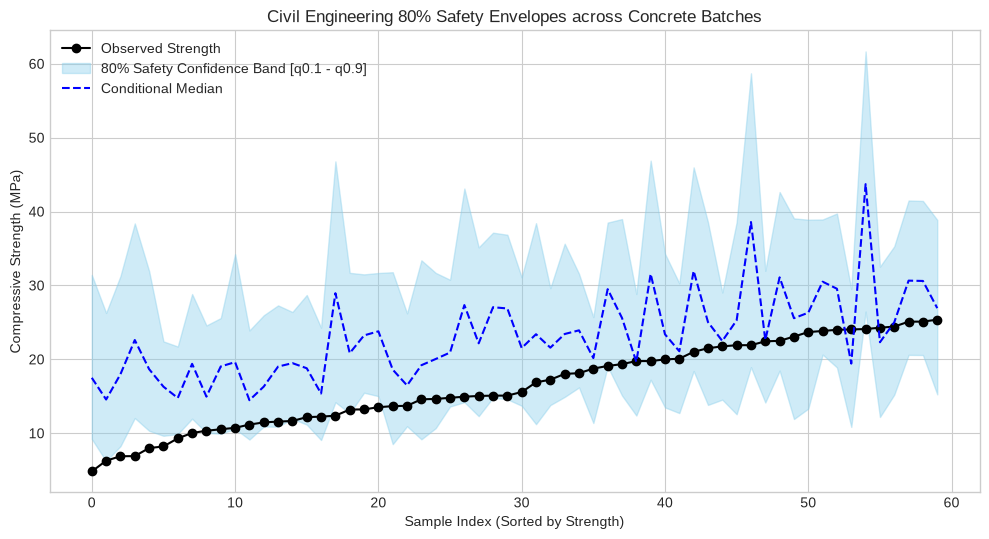

In [6]:
# STEP 8: INTERVAL VISUALIZATION
test_df = pd.DataFrame({
    'Actual': y_test.values,
    'Q10_Lower': predictions[0.1],
    'Q50_Median': predictions[0.5],
    'Q90_Upper': predictions[0.9]
}).sort_values('Actual').reset_index(drop=True)

plt.figure(figsize=(12, 6))
plt.plot(test_df.index[:60], test_df['Actual'][:60], 'ko-', label='Observed Strength')
plt.fill_between(test_df.index[:60], test_df['Q10_Lower'][:60], test_df['Q90_Upper'][:60], color='skyblue', alpha=0.4, label='80% Safety Confidence Band [q0.1 - q0.9]')
plt.plot(test_df.index[:60], test_df['Q50_Median'][:60], 'b--', label='Conditional Median')
plt.xlabel('Sample Index (Sorted by Strength)')
plt.ylabel('Compressive Strength (MPa)')
plt.title('Civil Engineering 80% Safety Envelopes across Concrete Batches')
plt.legend()
plt.show()


In [7]:
# STEP 9: 5-FOLD CV PINBALL LOSS STABILITY
cv5 = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(models[0.5], X, y, cv=cv5, scoring='neg_mean_absolute_error')
print(f"5-Fold CV Median MAE: {-scores.mean():.4f} +/- {scores.std():.4f}")


5-Fold CV Median MAE: 8.3555 +/- 0.6957


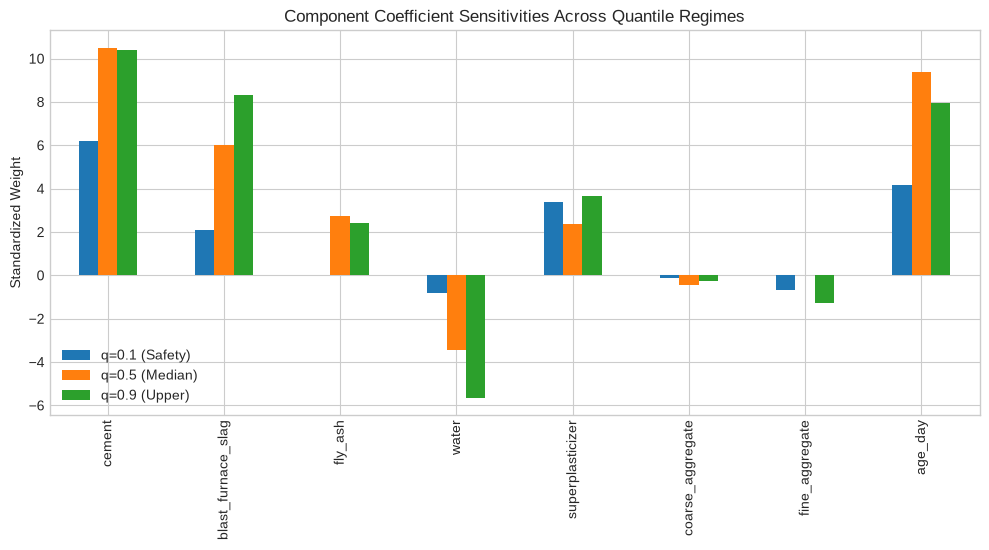

In [8]:
# STEP 10: COEFFICIENT DISCREPANCIES ACROSS QUANTILES
coef_df = pd.DataFrame({
    'q=0.1 (Safety)': models[0.1].named_steps['regressor'].coef_,
    'q=0.5 (Median)': models[0.5].named_steps['regressor'].coef_,
    'q=0.9 (Upper)':  models[0.9].named_steps['regressor'].coef_
}, index=features)
coef_df.plot(kind='bar', figsize=(12, 5))
plt.title('Component Coefficient Sensitivities Across Quantile Regimes')
plt.ylabel('Standardized Weight')
plt.show()


In [9]:
# STEP 11: PRODUCTION SERIALIZATION OF SAFETY SUITE
os.makedirs('production_models', exist_ok=True)
model_path = 'production_models/concrete_quantile_safety_suite.joblib'
joblib.dump(models, model_path, compress=3)
print(f"Saved Multi-Quantile Suite to: {model_path}")


Saved Multi-Quantile Suite to: production_models/concrete_quantile_safety_suite.joblib


In [10]:
# STEP 12: REAL-TIME LATENCY SMOKE TEST
loaded_suite = joblib.load(model_path)
sample = X_test.iloc[[0]]

lats = []
for _ in range(100):
    t0 = time.perf_counter()
    _ = {q: m.predict(sample)[0] for q, m in loaded_suite.items()}
    lats.append((time.perf_counter() - t0) * 1000)
avg_lat = np.mean(lats)
print(f"Mean 3-Quantile Latency: {avg_lat:.4f} ms | P99: {np.percentile(lats, 99):.4f} ms")
assert avg_lat < 15.0, "Latency SLA violated"
print("✅ Production Multi-Quantile Safety SLA Passed")


Mean 3-Quantile Latency: 2.1993 ms | P99: 3.4066 ms
✅ Production Multi-Quantile Safety SLA Passed


# STEP 13: EXECUTIVE DECISION MATRIX
| Model | Output Focus | Empirical Coverage | Civil Engineering Action |
| :--- | :--- | :--- | :--- |
| **OLS** | Mean Expectation | None (Point estimate) | Blind to catastrophic batch failure |
| **Quantile $q=0.10$** | Characteristic Minimum | 10% lower tail | **Guarantees structural design thresholds** |
| **Quantile $q=0.50$** | Typical Median | Central tendency | Expected batch performance |
| **Quantile $q=0.90$** | Upper Ceiling | 90% upper tail | Maximum curing potential |
